# Questão 4 - Dados Públicos

In [27]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
import sqlite3
import matplotlib.pyplot as plt
# import duckdb
from IPython.display import Image, display
import requests

### Caminho base do projeto

In [28]:
BASE_PATH = Path().resolve()

while BASE_PATH.name != "lh-nautical-data-project":
    BASE_PATH = BASE_PATH.parent

print(f"BASE PATH: {BASE_PATH}")

BASE PATH: /media/richard/RichardData/lh-nautical-data-project


Caminhos para as pastas do projeto.

In [29]:
DATA_PATH = BASE_PATH / "data"

RAW_PATH = DATA_PATH / "raw"
STAGING_PATH = DATA_PATH / "staging"
INTERMEDIATE_PATH = DATA_PATH / "intermediate"
MARTS_PATH = DATA_PATH / "marts"

SQL_PATH = BASE_PATH / "sql"
IMAGES_PATH = BASE_PATH / "imagens"

Dados públicos do Olinda, sistema de APIs públicas do Banco Central

"A Plataforma Olinda é o módulo de regulação digital do Banco Central do Brasil"

Tive que colocar o periodo que eu precisava na própria URL, não consegui de outra forma

In [30]:


url = "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/CotacaoDolarPeriodo(dataInicial=@dataInicial,dataFinalCotacao=@dataFinalCotacao)?@dataInicial='01-01-2023'&@dataFinalCotacao='12-31-2024'&$top=10000&$format=json"

response = requests.get(url)
data = response.json()

cambio = pd.DataFrame(data['value'])

cambio['data'] = pd.to_datetime(cambio['dataHoraCotacao']).dt.date
cambio['taxa_cambio'] = cambio['cotacaoVenda']

cambio = cambio[['data', 'taxa_cambio']]
cambio = cambio.sort_values('data').drop_duplicates('data', keep='last')

cambio.head()

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855


Criar calendário completo + preencher com último valor conhecido

In [31]:
calendario = pd.DataFrame({
    'data': pd.date_range(
        start=cambio['data'].min(),
        end=cambio['data'].max()
    )
})

cambio['data'] = pd.to_datetime(cambio['data'])
cambio_completo = calendario.merge(cambio, on='data', how='left')
cambio_completo['taxa_cambio'] = cambio_completo['taxa_cambio'].ffill()

cambio_completo.head(10)

,data,taxa_cambio
0,2023-01-02,5.3436
1,2023-01-03,5.3759
2,2023-01-04,5.4459
3,2023-01-05,5.4026
4,2023-01-06,5.2855
5,2023-01-07,5.2855
6,2023-01-08,5.2855
7,2023-01-09,5.2967
8,2023-01-10,5.2395
9,2023-01-11,5.2020


Salvei a tabela para analisar com SQL.

In [32]:
cambio_completo.to_csv(STAGING_PATH /"cambio_diario.csv", index=False)

Usei as tabelas da camada staging, que eu já havia tratado na etapa de EDA e limpeza, para garantir consistência dos tipos, nomes de colunas e evitar inconsistências.

In [33]:
df_vendas = pd.read_csv(STAGING_PATH / "stg_vendas.csv")
df_custos = pd.read_csv(STAGING_PATH / "stg_custos_importacao_tratado.csv")
df_cambio = pd.read_csv(STAGING_PATH / "cambio_diario.csv")

print("=== VENDAS ===")
print(df_vendas.columns.tolist())
print(df_vendas.head(2))
print()

print("=== CUSTOS ===")
print(df_custos.columns.tolist())
print(df_custos.head(2))
print()

print("=== CAMBIO ===")
print(df_cambio.columns.tolist())
print(df_cambio.head(2))
print()

=== VENDAS ===
['id_venda', 'id_cliente', 'id_produto', 'quantidade', 'valor_total', 'data_venda']
   id_venda  id_cliente  id_produto  quantidade  valor_total  data_venda
0      1230          17          91           4     512566.8  2023-01-01
1      2300          30          95           9     596858.4  2023-01-01

=== CUSTOS ===
['id_produto', 'nome_produto', 'categoria', 'data_inicio', 'preco_usd']
   id_produto                 nome_produto    categoria data_inicio  preco_usd
0           1  Transponder Ais Maré Magnum  eletrônicos  2016-08-10   10583.63
1           1  Transponder Ais Maré Magnum  eletrônicos  2018-06-15    8778.36

=== CAMBIO ===
['data', 'taxa_cambio']
         data  taxa_cambio
0  2023-01-02       5.3436
1  2023-01-03       5.3759



Optei por usar custo mais recente por produto

Parte 1 - Cálculo e modelagem

• Calcule o custo total e m BRL por transação

• Identifique transações com prejuízo

• Agregue os dados por id_produto, gerando:
1. Receita total (BRL)
2. Prejuízo total (BRL)
3. Percentual de perda (prejuízo_total /
receita_total)

In [34]:
query_path = SQL_PATH / "4_1_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Questão 4.1 - Código SQL: {SQL_PATH / '4_1_codigo.sql'}")


Questão 4.1 - Código SQL: /media/richard/RichardData/lh-nautical-data-project/sql/4_1_codigo.sql


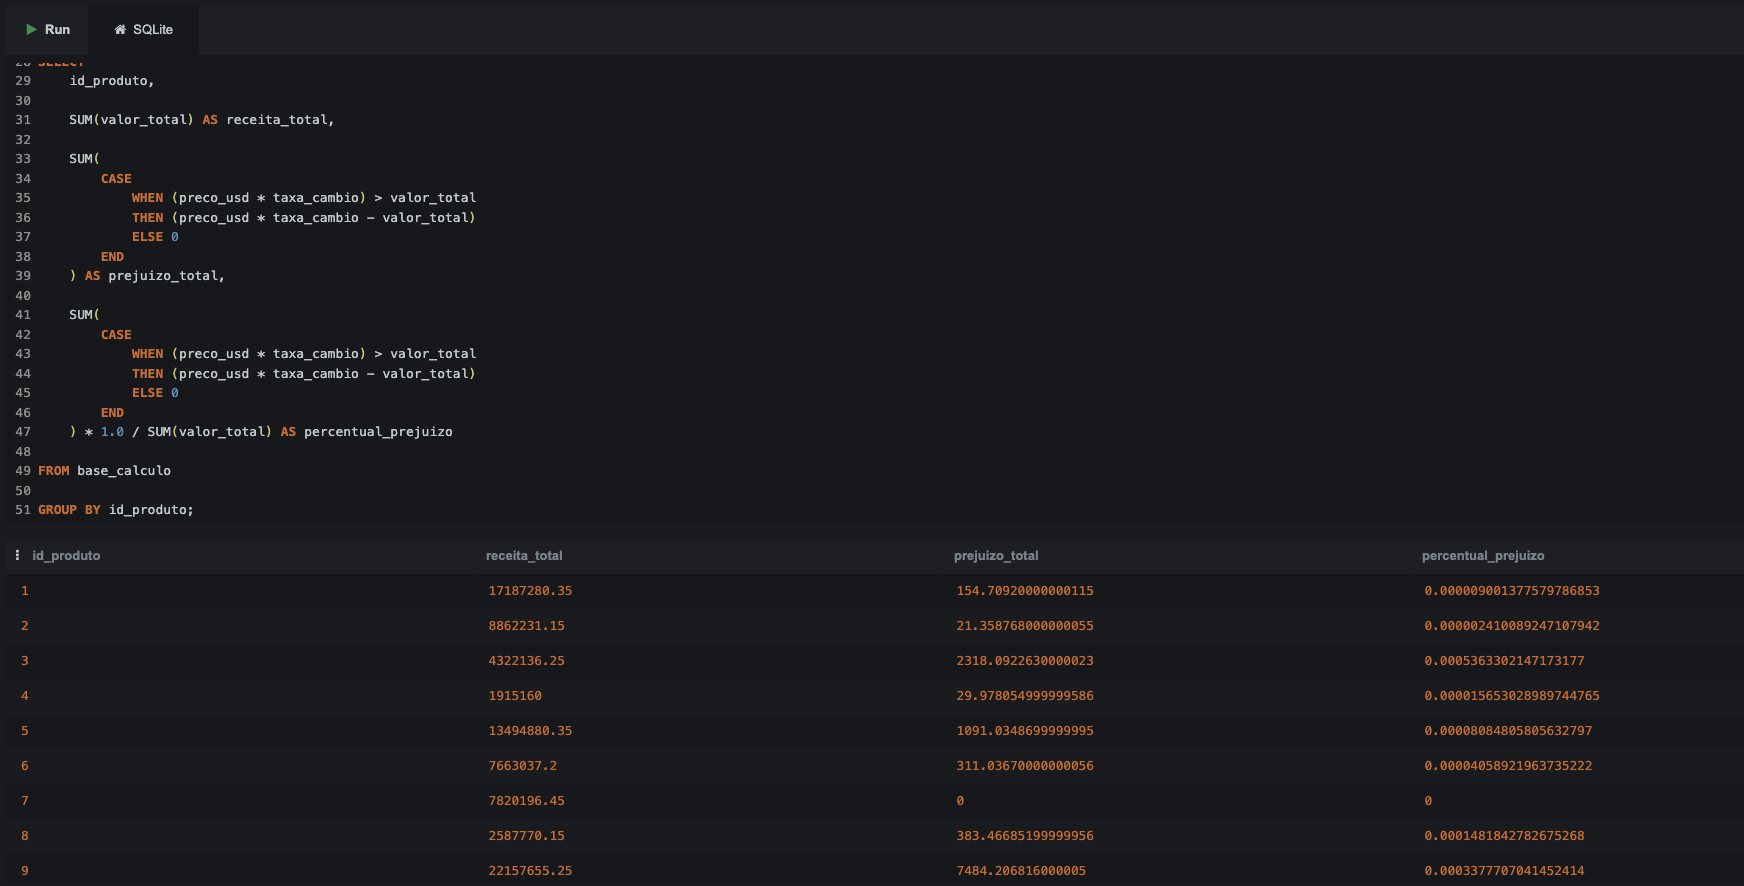

In [35]:
display(Image(filename=IMAGES_PATH / "4_1_codigo.png"))

Questão 4.2 - Validação.

Qual é o id_produto que apresentou a maior
porcentagem de perda financeira relativa (maior % de
prejuízo sobre sua receita) no período analisado? = 104

In [36]:
query_path = SQL_PATH / "4_2_codigo.sql"

with open(query_path, "r", encoding="utf-8") as f:
    query = f.read()

print(f"Questão 4.2 - Validação: {SQL_PATH / '4_2_codigo.sql'}")


Questão 4.2 - Validação: /media/richard/RichardData/lh-nautical-data-project/sql/4_2_codigo.sql


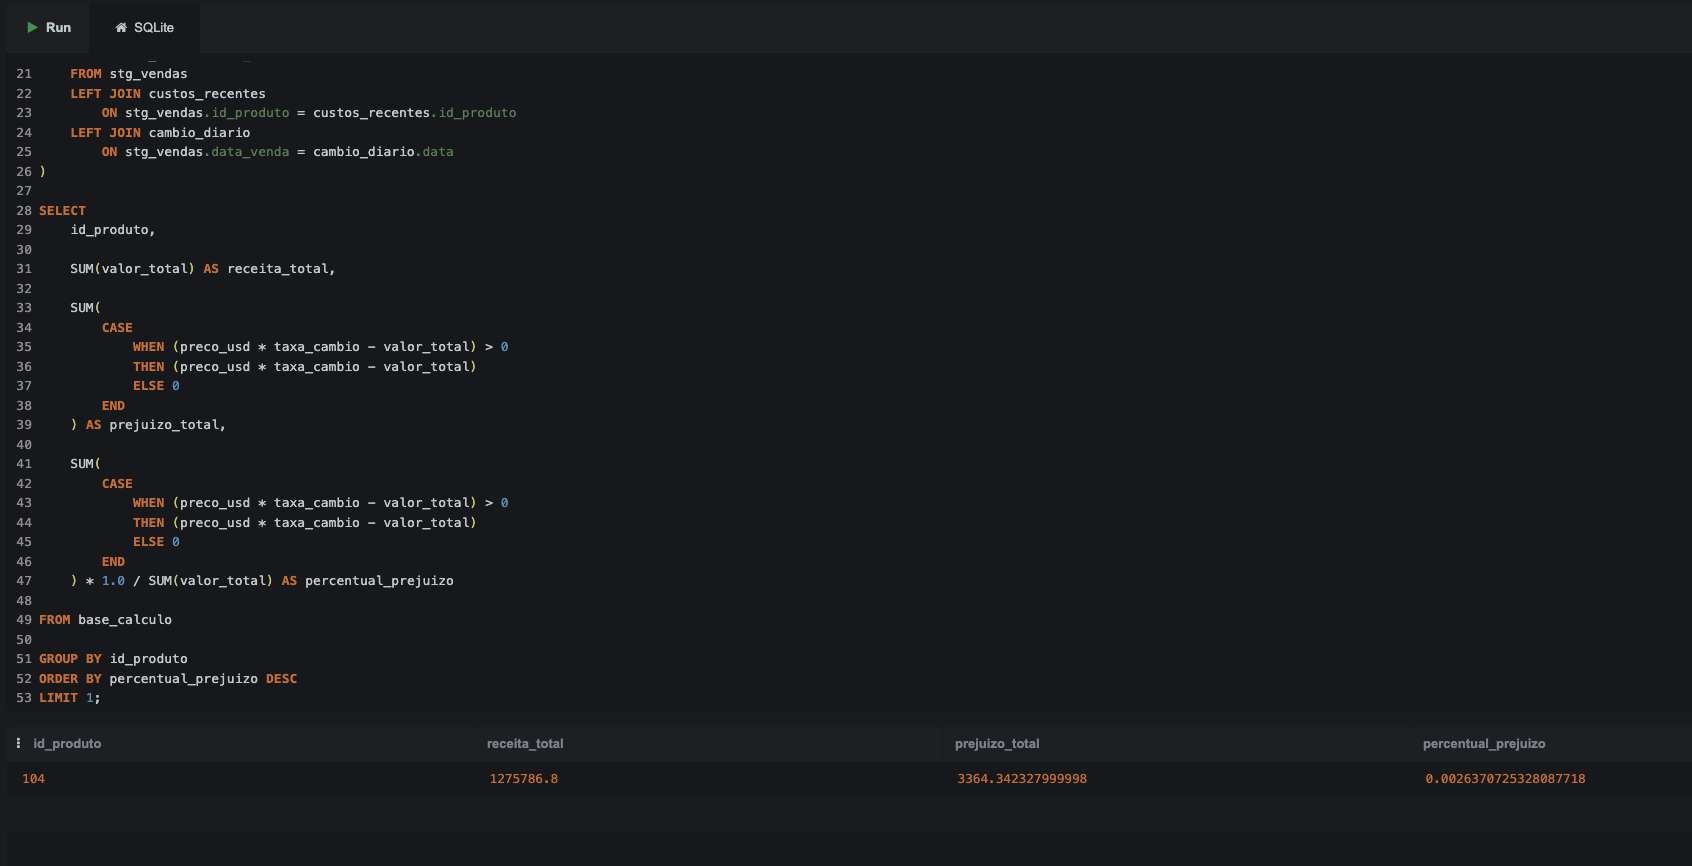

In [37]:
display(Image(filename=IMAGES_PATH / "4_2_codigo.png"))

## Questão 4.1 - Código Python + SQL

Parte 1 - Cálculo e modelagem

In [38]:
conn = sqlite3.connect(":memory:")

pd.read_csv("../data/staging/stg_vendas.csv").to_sql("stg_vendas", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv").to_sql("stg_custos", conn, index=False, if_exists="replace")
pd.read_csv("../data/staging/cambio_diario.csv").to_sql("cambio", conn, index=False, if_exists="replace")

730

Conferindo a granularidade dos dados

Para stg_vendas.csv

In [39]:
query = """
SELECT 
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_venda) AS vendas_unicas
FROM stg_vendas
"""
base_vendas = pd.read_sql_query(query, conn)
base_vendas.head()

,total_linhas,vendas_unicas
0,9895,9895


E para cambio_diario.csv

In [40]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT data) AS datas_unicas
FROM cambio
"""

pd.read_sql_query(query, conn)

,total_linhas,datas_unicas
0,730,730


Para stg_custos_importacao_tratado.csv

In [41]:
query = """
SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT id_produto) AS produtos_unicos
FROM stg_custos
"""

pd.read_sql_query(query, conn)

,total_linhas,produtos_unicos
0,1260,150


Optei por usar custo mais recente por produto

Parte 1 - Cálculo e modelagem
• Calcule o custo total e m BRL por transação
• Identifique transações com prejuízo
• Agregue os dados por id_produto, gerando:
1. Receita total (BRL)
2. Prejuízo total (BRL)
3. Percentual de perda (prejuízo_total /
receita_total)

In [42]:
query = """
WITH custos_recentes AS (
    SELECT
        id_produto,
        preco_usd
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY id_produto
                   ORDER BY data_inicio DESC
               ) as rn
        FROM stg_custos
    )
    WHERE rn = 1
)

SELECT
    v.id_produto,
    SUM(v.valor_total) AS receita_total,
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) AS prejuizo_total,
    
    SUM(
        CASE 
            WHEN (c.preco_usd * tc.taxa_cambio - v.valor_total) > 0 
            THEN (c.preco_usd * tc.taxa_cambio - v.valor_total)
            ELSE 0
        END
    ) * 1.0 / SUM(v.valor_total) AS percentual_prejuizo

FROM stg_vendas v

LEFT JOIN custos_recentes c
    ON v.id_produto = c.id_produto

LEFT JOIN cambio tc
    ON v.data_venda = tc.data

GROUP BY v.id_produto
"""

resultado = pd.read_sql_query(query, conn)

resultado.head()

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
0,1,17187280.35,154.709200,0.000009
1,2,8862231.15,21.358768,0.000002
2,3,4322136.25,2318.092263,0.000536
3,4,1915160.00,29.978055,0.000016
4,5,13494880.35,1091.034870,0.000081


In [43]:
resultado.to_csv("../data/staging/indicadores_financeiros_produtos.csv", index=False)

Parte 2 - Análise visual

In [44]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [45]:
df["produto_label"] = df["nome_produto"] + " (ID " + df["id_produto"].astype(str) + ")"

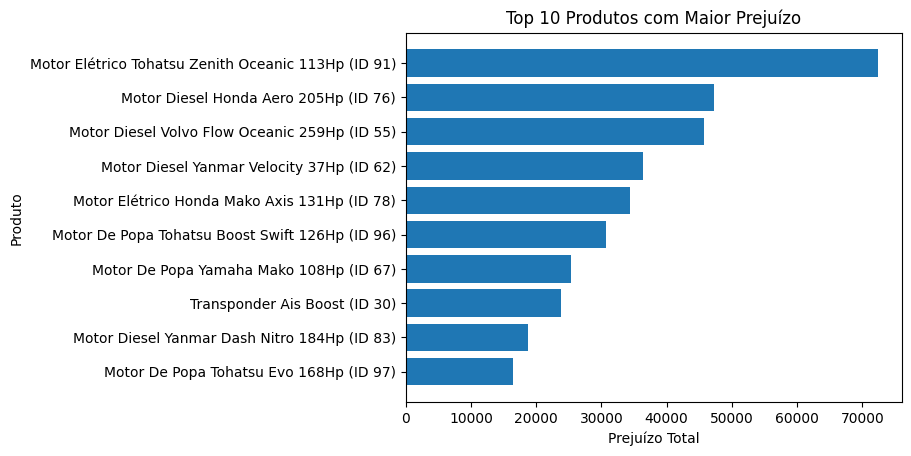

In [46]:
top10 = df.sort_values("prejuizo_total", ascending=False).head(10)

plt.figure()
plt.barh(top10["produto_label"], top10["prejuizo_total"])
plt.title("Top 10 Produtos com Maior Prejuízo")
plt.xlabel("Prejuízo Total")
plt.ylabel("Produto")
plt.gca().invert_yaxis()

plt.show()

Parte 3 - Análise objetiva Responda

In [47]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")

In [48]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df_produtos = pd.read_csv("../data/staging/stg_custos_importacao_tratado.csv")
df_produtos = df_produtos[["id_produto", "nome_produto"]].drop_duplicates()
df = df.merge(df_produtos, on="id_produto", how="left")

In [49]:
maior_prejuizo = df.loc[[df["prejuizo_total"].idxmax()]]
maior_prejuizo[["id_produto", "nome_produto", "prejuizo_total"]]

,id_produto,nome_produto,prejuizo_total
90,91,Motor Elétrico Tohatsu Zenith Oceanic 113Hp,72420.727535


In [50]:
maior_percentual = df.loc[[df["percentual_prejuizo"].idxmax()]]
maior_percentual[["id_produto", "nome_produto", "percentual_prejuizo"]]

,id_produto,nome_produto,percentual_prejuizo
103,104,Cabo De Nylon Delta Zen Vortex Storm,0.002637


In [51]:
produto_abs = maior_prejuizo["id_produto"].values[0]
produto_pct = maior_percentual["id_produto"].values[0]

nome_abs = maior_prejuizo["nome_produto"].values[0]
nome_pct = maior_percentual["nome_produto"].values[0]

mesmo = produto_abs == produto_pct

print(f"Produto com maior prejuízo absoluto: {nome_abs}")

if mesmo:
    print("É o mesmo produto com maior percentual de perda: SIM")
else:
    print("É o mesmo produto com maior percentual de perda: NÃO")
    print(f"Produto com maior percentual de perda: {nome_pct}")

Produto com maior prejuízo absoluto: Motor Elétrico Tohatsu Zenith Oceanic 113Hp
É o mesmo produto com maior percentual de perda: NÃO
Produto com maior percentual de perda: Cabo De Nylon Delta Zen Vortex Storm


Questão 4.2 - Validação.

Qual é o id_produto que apresentou a maior
porcentagem de perda financeira relativa (maior % de
prejuízo sobre sua receita) no período analisado? = 104

In [52]:
df = pd.read_csv("../data/staging/indicadores_financeiros_produtos.csv")
df.loc[[df["percentual_prejuizo"].idxmax()]]

,id_produto,receita_total,prejuizo_total,percentual_prejuizo
103,104,1275786.8,3364.342328,0.002637


Questão 4.3 - Interpretação

Qual data de câmbio você utilizou?

Utilizei a taxa de câmbio do dia da venda "data_venda", com um join da tabela de câmbio diário "cambio_diario" usando as datas.

Como definiu o prejuízo?

O prejuízo foi calculado da diferença entre o custo do produto convertido em BRL e o valor total da venda. Quando o custo em BRL (preco_usd * taxa_cambio) foi maior que o valor da venda, a transação teve prejuízo.

Alguma suposição relevante?

Usei o custo mais recente de cada produto, com base na data de início "data_inicio", para simplificar o modelo.